In [5]:
import pandas as pd
import numpy as np
from sklearn.covariance import GraphicalLasso
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from functions.SQUIC_functions import squic_fit_sparse, squic_fit_matrix_sparse, check_symmetric_sparse
from functions.clustering_functions import clustering_optimal_number, modularity_density
from networkx.algorithms import community
import igraph as ig
import leidenalg as la
from sklearn.cluster import DBSCAN, SpectralClustering
from functions.spectral_clustering import find_optimal_clusters, compute_spectral_clustering, compute_normalized_laplacian, compute_eigenvalues_eigenvectors
from functions.internal import load_dataset_1A
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.neighbors import NearestNeighbors
import os
from matplotlib.gridspec import GridSpec
from functions.plots import plot_timeseries
from matplotlib.lines import Line2D
from functions.cosmograph_functions import cosmograph_decomposition, cosmograph_from_theta

In [6]:
def internal_density(G, community, n, density_sum):
    subgraph = G.subgraph(community)
    m = subgraph.number_of_edges()
    max_possible = n * (n - 1) / 2
    density_sum += m / max_possible # internal density of single comm
    return density_sum


def labels_to_partition(labels):
    """Convert label array [0,0,1,1,2,2] -> list of sets [{0,1},{2,3},{4,5}]"""
    clusters = {}
    for idx, label in enumerate(labels):
        if label not in clusters:
            clusters[label] = set()
        clusters[label].add(idx)

    # Remove noise points if using DBSCAN (-1 labels)
    if -1 in clusters:
        noise_nodes = clusters.pop(-1)
        for node in noise_nodes:
            clusters[f'noise_{node}'] = {node}  # unique labels for noise

    return list(clusters.values())


def compute_partition_density(G, community, D_sum):
    n_alpha = len(community)

    subgraph = G.subgraph(community)
    m_alpha = subgraph.number_of_edges()

    numerator = m_alpha - (n_alpha - 1)
    denominator = (n_alpha - 2) * (n_alpha - 1)

    if denominator > 0:
        D_sum += m_alpha * (numerator / denominator)
    return D_sum

In [7]:
SAVE_FIG_DIR = 'decomposition/glasso_images/paysim'
PLOT = False
SAVE_FIG = False
SEASONAL_PERIOD = 7

First pass: Identifying users and fraud accounts...
Found 111 unique users
Found 24 fraud accounts
Second pass: Processing transactions and building matrices...
Data with 359 samples after decomposition.
-> Standardizing (normalizing) data...
(359, 111)
(111, 359)
-> Running SQUIC-Fit with lambda = 0.6...
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 359 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      6.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=9.0

/var/folders/s6/4jprwbqj4012tkll2ww6r5hr0000gq/T/ipykernel_25173/1948993614.py:381: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


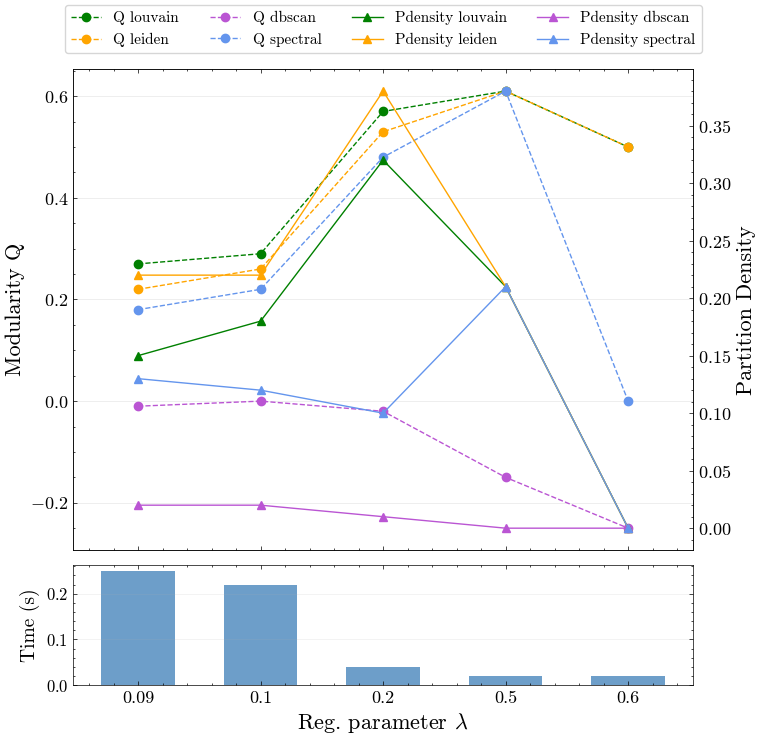

In [8]:
Y, _, dim, _ = load_dataset_1A()

if PLOT:
    plot_timeseries(Y, "PAYSIM", dimension=dim, save_fig=SAVE_FIG_DIR, title="timeseries")

all_residuals = { 
            account: seasonal_decompose(Y[account], model='additive', period=SEASONAL_PERIOD).resid
            for account in Y.columns
        }
df_residuals = pd.DataFrame(all_residuals).dropna()
print(f"Data with {df_residuals.shape[0]} samples after decomposition.")

print("-> Standardizing (normalizing) data...")
residuals_matrix = df_residuals.values
col_std = np.std(residuals_matrix, axis=0, keepdims=True)
col_std[col_std == 0] = 1.0
prepared_data = residuals_matrix / col_std

if PLOT:
    df_prepared = pd.DataFrame(prepared_data, 
                    index=df_residuals.index, 
                    columns=df_residuals.columns)
    
    print(df_prepared)


    plt.figure(figsize=(9,7))

    for user in df_prepared.columns:
        if user[0] == 'B':
            pass
        else:
            plt.plot(df_prepared.index, df_prepared[user], label=f"User {user}", alpha=0.7)

    # --- Formatting ---
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.xlabel("Days", fontsize=18)
    plt.ylabel("Balance", fontsize=18)
    plt.tick_params(axis='x', labelsize=18)
    plt.tick_params(axis='y', labelsize=18)
    plt.grid(axis='y', color='#cccccc', linewidth=0.5, alpha=0.3, linestyle='--')
    plt.grid(axis='x', color='#cccccc', linewidth=0.5, alpha=0.3, linestyle='--')
    plt.tight_layout()

    if SAVE_FIG:
        path = f'{SAVE_FIG_DIR}/{dim}'
        os.makedirs(path, exist_ok=True)
        plt.savefig(f'{path}/timeseries_norm', dpi=300)
    plt.show()

print(prepared_data.shape)
prepared_data = prepared_data.T

print(prepared_data.shape)

if input("Do you want to cache this data?").upper() == 'Y':
    print("Saving data")
    path = f'decomposition/paysim_data_saved/{dim}'

    # if path does not exists, create it
    os.makedirs(path, exist_ok=True)
    
    # Save Y_norm as CSV
    pd.DataFrame(prepared_data).to_csv(f'{path}/YNorm_{dim}.csv', index=False)

ROWS = prepared_data.shape[0]

# reg. parameter glasso
if dim == '100':
    lambdas = [0.6, 0.5, 0.2, 0.1, 0.09]
elif dim == '1K':
    lambdas = [0.9, 0.7, 0.5, 0.3]
    # lambdas = [0.9995, 0.999, 0.95, 0.9, 0.7, 0.5]
elif dim == '10K':
    lambdas = [0.995, 0.9, 0.8, 0.75, 0.7]
elif dim == '100K':
    # lambdas = [0.99999, 0.99995, 0.9999]
    # lambdas = [0.9999, 0.9995, 0.999, 0.995, 0.99] # w/o bias
    lambdas = [0.99, 0.95, 0.9, 0.85] # w/o bias

int_metrics = {
    rho: {
        'louvain': {},
        'leiden': {},
        'dbscan': {},
        'spectral': {}
    } for rho in lambdas
}

bias = input("Do you want to run SQUIC-Fit with bias? (Y/N)").upper()
if bias == 'Y':
    n_neigs = {
        '100' : 10,
        '1K' : 10,
        '10K' : 4, # before it was 4
        '100K' : 3, # can run even with 4
        '1M' : 2
    }

    nbrs = NearestNeighbors(n_neighbors=n_neigs[dim], metric='euclidean', n_jobs=-1)
    nbrs.fit(prepared_data)
    knn_matrix = nbrs.kneighbors_graph(prepared_data, mode='connectivity')
    
    print("Shape KNN:", knn_matrix.shape)
    print("nnz KNN:", knn_matrix.nnz)

    # if PLOT:
    #     plt.figure(figsize=(7, 7))
    #     plt.spy(knn_matrix, markersize=5)
    #     plt.xlabel("Users", fontsize=18)
    #     plt.ylabel("Users", fontsize=18)
    #     plt.tick_params(axis='x', labelsize=18)
    #     plt.tick_params(axis='y', labelsize=18)
    #     plt.title(f"KNN with K={n_neigs[dim]}", fontsize=16)
    #     if SAVE_FIG:
    #         path = f'{SAVE_FIG_DIR}/{dim}'
    #         os.makedirs(path, exist_ok=True)
    #         lambda_str = str(LAMBDA).replace(".", "")
    #         plt.savefig(f"{path}/knn_{lambda_str}", dpi=300)
    #     plt.show()

widget_dict = {}
widget_cluster_dict = {}
results_squic = {}

for LAMBDA in lambdas:
    # Run SQUIC-Fit ---
    print(f"-> Running SQUIC-Fit with lambda = {LAMBDA}...")
    if bias == 'N':
        model_fit, end_time = squic_fit_sparse(prepared_data, LAMBDA, LAMBDA/10)
    else:
        model_fit, end_time = squic_fit_matrix_sparse(prepared_data, LAMBDA, knn_matrix)

    end_time = round(end_time, 2)
    results_squic[LAMBDA] = model_fit
    print(f"required time: {end_time}")

    int_metrics[LAMBDA]['time'] = end_time

    nnz = model_fit.count_nonzero()
    print(f"nnz = {int(nnz)} per rows = {round(int(nnz)/ROWS, 2)}")

    if check_symmetric_sparse(model_fit):
        print(f" Matrix is symmetric per rho {LAMBDA}")
    else:
        print(f" Matrix is not symmetric per rho {LAMBDA}")

    if PLOT:
        plt.figure(figsize=(7, 7))
        plt.spy(model_fit, markersize=5)
        # plt.xlabel("Users", fontsize=18)
        plt.xlabel("Users", fontsize=18)
        plt.ylabel("Users", fontsize=18)

        plt.tick_params(axis='x', labelsize=18)
        plt.tick_params(axis='y', labelsize=18) 
        if SAVE_FIG:
            path = f'{SAVE_FIG_DIR}/{dim}'
            os.makedirs(path, exist_ok=True)
            lambda_str = str(LAMBDA).replace(".", "")
            if bias == 'N':
                plt.savefig(f"{path}/squic_fit_{lambda_str}", dpi=300)
            else:
                plt.savefig(f"{path}/squic_fit_{lambda_str}_bias", dpi=300)
        plt.show()

    widget_dict = cosmograph_from_theta(model_fit, LAMBDA, widget_dict)

    dict_cluster = {
        "louvain" : {},
        "spectral" : {},
        "dbscan" : {},
        "leiden" : {}
    }

    dbscan_params_dict = {
        '100' : {'epsilon' : 0.7,
                'min_samples' : 8},
        '1K' : {'epsilon' : 0.7,
                'min_samples' : 3},
        '10K' : {'epsilon' : 0.7,
                'min_samples' : 3},
        '100K' : {'epsilon' : 0.7,
                'min_samples' : 3},
        '1M' : {'epsilon' : 0.7,
                'min_samples' : 3}
    }

    # Ensure all off-diagonal entries are positive
    X = np.abs(model_fit) 

    # Ensure diagonal entries are zero
    X.setdiag(0) # SQUIC_Fit ensure that, SQUIC not, so manually turn into 0

    # Create a graph from matrix X
    G = nx.from_scipy_sparse_array(X)

    connected = nx.is_connected(G)
    print(f"Is G connected for l={LAMBDA}? {connected}")
    if not connected:
        connected_components = nx.connected_components(G)
        component_sizes = [len(c) for c in connected_components]
        print(f"# CC : {len(component_sizes)}")

    # Louvain
    partition_louvain = community.louvain_communities(G)
    dict_cluster['louvain'] = partition_louvain

    # Leiden
    G_igraph = ig.Graph.from_networkx(G)
    partition_leiden = la.find_partition(G_igraph, la.ModularityVertexPartition)
    dict_cluster['leiden'] = partition_leiden

    dbscan = DBSCAN(eps=dbscan_params_dict[dim]['epsilon'],
                        min_samples=dbscan_params_dict[dim]['min_samples'],
                        metric='cosine')
    labels_dbscan = dbscan.fit_predict(X)

    # Convert labels to list of sets
    partition_dbscan = labels_to_partition(labels_dbscan)
    dict_cluster['dbscan'] = partition_dbscan

    # Spectral Clustering
    optimal_k, eigenvectors = find_optimal_clusters(G, dim, plot=False)
    if eigenvectors is not None:
        labels_spectral = compute_spectral_clustering(eigenvectors, optimal_k, method='kmeans', plot=False)
        # Convert labels to list of sets
        partition_spectral = labels_to_partition(labels_spectral)

        dict_cluster['spectral'] = partition_spectral
    else:
        dict_cluster['spectral'] = None

    widget_cluster_dict = cosmograph_decomposition(widget_cluster_dict, model_fit, LAMBDA, dict_cluster)

    for method, partition in dict_cluster.items():
        print(method)

        # Skip if partition is None
        if partition is None:
            print(f"[Warning] No partition for method={method}, lambda={LAMBDA}. Skipping.")

            int_metrics[LAMBDA][method]["p_density"] = 0
            int_metrics[LAMBDA][method]['modularity'] = 0
            int_metrics[LAMBDA][method]['CC'] = 0
            int_metrics[LAMBDA][method]['nCluster'] = 0
            int_metrics[LAMBDA][method]['isolated'] = "all isolated elements"
        else:
            # Ensure all off-diagonal entries are positive
            X = np.abs(X) 

            # Ensure diagonal entries are zero
            X.setdiag(0) # SQUIC_Fit ensure that, SQUIC not, so manually turn into 0

            # G = nx.from_numpy_array(X)
            G = nx.from_scipy_sparse_array(X)
            
            m_total = G.number_of_edges()
            D_sum = 0
            isolated_node = 0
            density_sum = 0

            for comm in partition:
                n = len(comm)
                if n == 1:
                    isolated_node += 1
                    continue
                else:
                    density_sum = internal_density(G, comm, n, density_sum)

                    if n >= 3: # skip communities too small for partition density
                        D_sum = compute_partition_density(G, comm, D_sum)
            
            avg_internal_density = density_sum / len(partition) # avg internal density
            int_metrics[LAMBDA][method]["int_density"] = float(round(avg_internal_density, 2))

            partition_density = (2 / m_total) * D_sum if m_total > 0 else 0
            int_metrics[LAMBDA][method]["p_density"] = float(round(partition_density, 2))

            modularity = community.modularity(G, partition)
            int_metrics[LAMBDA][method]['modularity'] = float(round(modularity, 2))

            int_metrics[LAMBDA][method]["isolated"] = isolated_node
            
            # Connected Components
            int_metrics[LAMBDA][method]['CC'] = nx.number_connected_components(G)

            # N cluster
            int_metrics[LAMBDA][method]['nCluster'] = len(partition)

for rho, results in int_metrics.items():
    print(f"Lambda = {rho}")
    print()
    for method, metrics in results.items():
        if method == 'time':
            pass
        else:
            print(f"    {method} : #Cluster = {metrics['nCluster']}, int_density = {metrics['int_density']}, p_density = {metrics['p_density']}, Q = {metrics['modularity']}")


colors = {
    'louvain': 'green',
    'leiden': 'orange',
    'spectral': 'cornflowerblue',
    'dbscan': 'mediumorchid'
}

# figure with a short time panel below
fig = plt.figure(figsize=(8, 8))
gs = GridSpec(nrows=2, ncols=1, height_ratios=[4, 1], hspace=0.05)
ax1 = fig.add_subplot(gs[0, 0])          # Q (left y)
ax2 = ax1.twinx()                         # Pdensity (right y)
ax_time = fig.add_subplot(gs[1, 0], sharex=ax1)

# Collect the sorted unique rho values (λ) for x (equally spaced categories)
all_rhos = sorted(int_metrics.keys())
x_pos_map = {rho: i for i, rho in enumerate(all_rhos)}  # rho -> index 0..N-1

# Methods present in the first rho entry — keep only dict-valued keys (exclude 'time')
first_rho = all_rhos[0]
clustering_methods = [k for k, v in int_metrics[first_rho].items() if isinstance(v, dict)]

# --- Time panel data (seconds) ---
time_values, time_x = [], []
for rho in all_rhos:
    end_time = int_metrics.get(rho, {}).get('time', np.nan)  # float seconds
    # if some entry is missing or NaN, keep NaN (line plot will skip; bar will show 0 if we choose to)
    time_values.append(end_time)
    time_x.append(x_pos_map[rho])

# --- Top panel: Q and Pdensity for each method ---
for method in clustering_methods:
    x_idx, q_vals, pden_vals = [], [], []
    for rho in all_rhos:
        mm = int_metrics.get(rho, {}).get(method, None)
        if not isinstance(mm, dict):
            continue
        pdens = mm.get('p_density', None)
        modularity = mm.get('modularity', None)
        if (pdens is not None) and (modularity is not None):
            x_idx.append(x_pos_map[rho])
            q_vals.append(modularity)
            pden_vals.append(pdens)

    if x_idx:
        c = colors.get(method, 'black')
        ax1.plot(x_idx, q_vals, linestyle='--', marker='o', color=c, label=f'Q {method}')
        ax2.plot(x_idx, pden_vals, linestyle='-', marker='^', color=c, label=f'Pdensity {method}')

# ===== top axes labels & ticks =====
ax1.set_ylabel('Modularity Q', color='black', fontsize=16)
ax2.set_ylabel('Partition Density', color='black', fontsize=16)
ax1.set_xticks(range(len(all_rhos)))
ax1.set_xticklabels([str(r) for r in all_rhos], fontsize=13)
ax1.tick_params(axis='y', labelsize=13)
ax2.tick_params(axis='y', labelsize=13)
ax1.grid(True, axis='y', alpha=0.3)

# unified legend (top plot)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
        loc='upper center', bbox_to_anchor=(0.5, 1.15),
        ncol=4, fontsize=11, frameon=True)

# ===== bottom time panel (seconds) =====
time_values = np.array(time_values, dtype=float)
# bars (replace NaN with 0 for bars; or switch to a line plot to skip NaNs)
ax_time.bar(time_x, np.nan_to_num(time_values, nan=0.0),
            width=0.6, alpha=0.6, linewidth=0.5)

ax_time.set_ylabel('Time (s)', fontsize=14)
ax_time.set_xlabel(r'Reg. parameter $\lambda$', fontsize=16)
ax_time.tick_params(axis='x', labelsize=13)
ax_time.tick_params(axis='y', labelsize=12)
ax_time.grid(True, axis='y', alpha=0.2)

# hide duplicated x tick labels on top axis
plt.setp(ax1.get_xticklabels(), visible=False)

fig.tight_layout()
if SAVE_FIG:
    path = f'{SAVE_FIG_DIR}/{dim}'
    os.makedirs(path, exist_ok=True)
    if bias == 'N':
        plt.savefig(f'{path}/plot', dpi=300)
    else:
        plt.savefig(f'{path}/plot_bias', dpi=300)
plt.show()


In [9]:
widget_dict

{0.6: Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_color='#E3E3E3', link_greyout_opacity=0.1, link_source_by='source', link_target_by='target', link_width_by='weight', point_color='#0d5da4', point_size_by='degree', random_seed=None),
 0.5: Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_color='#E3E3E3', link_greyout_opacity=0.1, link_source_by='source', link_target_by='target', link_width_by='weight', point_color='#0d5da4', point_size_by='degree', random_seed=None),
 0.2: Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_color='#E3E3E3', link_greyout_opacity=0.1, link_source_by='source', link_target_by='target', link_width_by='weight', point_color='#0d5da4', point_size_by='degree', random_seed=None),
 0.1: Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_col

In [18]:
rho = 0.2

In [19]:
widget_dict[rho]

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…

In [20]:
widget_cluster_dict

{0.6: {'louvain': Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_color='#E3E3E3', link_greyout_opacity=0.1, link_source_by='source', link_target_by='target', link_width_by='weight', point_color=None, point_color_by='community', point_color_by_map=[['0', '#4682B4'], ['1', '#FF9999'], ['2', '#4169E1'], ['3', '#FFD700'], ['4', '#FFCC99'], ['5', '#CCFFE5'], ['6', '#FFFF99'], ['7', '#CCFF99'], ['8', '#CCFFFF'], ['9', '#CCCCFF'], ['10', '#E9967A'], ['11', '#E5CCFF'], ['12', '#DC143C'], ['13', '#FFFFFF'], ['14', '#F0FFF0']], point_color_strategy='map', point_size_by='degree', random_seed=None),
  'leiden': Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_color='#E3E3E3', link_greyout_opacity=0.1, link_source_by='source', link_target_by='target', link_width_by='weight', point_color=None, point_color_by='community', point_color_by_map=[['0', '#4682B4'], ['1', '#FF9999'], ['2', '#4

In [21]:
widget_cluster_dict[rho]['louvain']

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…

In [22]:
widget_cluster_dict[rho]['leiden']

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…

In [23]:
widget_cluster_dict[rho]['spectral']

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…

In [24]:
widget_cluster_dict[rho]['dbscan']

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…